<img src = "https://drive.google.com/uc?export=view&id=1vU_Lg5LD6Dn521znF_9E6OsJgwptOT9E" alt = "Encabezado MLDS" width = "100%">  </img>

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. ---**Alejandra Jaramillo Mejia**---
2. ---**Brayan Sebastian Yepes Garcia**---
3. ---**Santiago Chaparro Suzunaga**---

## **1. Adquisición e Integración de los Datos: Records**
---



In [1]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd()

# If the notebook is running inside notebooks/<folder>,
# move up until reaching the project root.
while not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Data directories
RAW_DATA = PROJECT_ROOT / "data" / "raw"
EEG_DATA = RAW_DATA / "eeg"
CLINICAL_DATA = RAW_DATA / "clinical"
INTERIM_DATA = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

# Results
RESULTS = PROJECT_ROOT / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"

# Create directories if needed
folders = [
    RAW_DATA,
    EEG_DATA,
    CLINICAL_DATA,
    INTERIM_DATA,
    PROCESSED_DATA,
    FIGURES,
    TABLES,
]

for folder in folders:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("EEG data:", EEG_DATA)
print("Clinical data:", CLINICAL_DATA)
print("Processed data:", PROCESSED_DATA)

Project root: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project
Raw data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw
EEG data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg
Clinical data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/clinical
Processed data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/processed


In [2]:
import sys
import os
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!pip install -q wfdb
import wfdb

In [4]:
from pathlib import Path
import requests
BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"


METADATA_DIR = RAW_DATA / "clinical"
METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Metadata directory:", METADATA_DIR)


Metadata directory: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/clinical


In [5]:
response = requests.get(RECORDS_URL)

response.raise_for_status()

records = response.text.splitlines() # split the text into a list of records

print(records)

NUMBER_OF_RECORDS = len(records)
print(f"Number of records: {NUMBER_OF_RECORDS}")

patient_ids = [
    record.strip("/").split("/")[-1]
    for record in records
]
print(patient_ids[:10])





#patient_data


['training/0284/', 'training/0286/', 'training/0296/', 'training/0299/', 'training/0303/', 'training/0306/', 'training/0311/', 'training/0312/', 'training/0313/', 'training/0316/', 'training/0319/', 'training/0320/', 'training/0326/', 'training/0328/', 'training/0332/', 'training/0334/', 'training/0335/', 'training/0337/', 'training/0340/', 'training/0341/', 'training/0342/', 'training/0344/', 'training/0346/', 'training/0347/', 'training/0348/', 'training/0349/', 'training/0350/', 'training/0351/', 'training/0352/', 'training/0353/', 'training/0354/', 'training/0355/', 'training/0356/', 'training/0357/', 'training/0358/', 'training/0359/', 'training/0360/', 'training/0361/', 'training/0362/', 'training/0363/', 'training/0364/', 'training/0365/', 'training/0366/', 'training/0367/', 'training/0368/', 'training/0369/', 'training/0370/', 'training/0371/', 'training/0372/', 'training/0373/', 'training/0375/', 'training/0376/', 'training/0377/', 'training/0378/', 'training/0379/', 'training

## Prueba de unicidad


In [ ]:

#patient_ids[0]
print("Number of patients:", len(patient_ids))
#This explores the number of unique patients in the dataset
print('Unique patients:', len(set(patient_ids)))
assert len(patient_ids) == len(set(patient_ids))
print('First patient ID:', patient_ids[0])
print('Last patient ID:', patient_ids[-1])

Number of patients: 607
Unique patients: 607
First patient ID: 0284
Last patient ID: 1020


In [7]:
sites = [
    {
        "site_id": 1,
        "hospital": "Rijnstate Hospital",
        "city": "Arnhem",
        "region": None,
        "country": "Netherlands",
        "investigators": ["Jeannette Hofmeijer"],
    },
    {
        "site_id": 2,
        "hospital": "Medisch Spectrum Twente",
        "city": "Enschede",
        "region": None,
        "country": "Netherlands",
        "investigators": [
            "Barry J. Ruijter",
            "Marleen C. Tjepkema-Cloostermans",
            "Michel J. A. M. van Putten",
        ],
    },
    {
        "site_id": 3,
        "hospital": "Erasme Hospital",
        "city": "Brussels",
        "region": None,
        "country": "Belgium",
        "investigators": ["Nicolas Gaspard"],
    },
    {
        "site_id": 4,
        "hospital": "Massachusetts General Hospital",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": [
            "Edilberto Amorim",
            "Wei-Long Zheng",
            "Mohammad Ghassemi",
            "M. Brandon Westover",
        ],
    },
    {
        "site_id": 5,
        "hospital": "Brigham and Women's Hospital",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": ["Jong Woo Lee"],
    },
    {
        "site_id": 6,
        "hospital": "Beth Israel Deaconess Medical Center",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": ["Susan T. Herman"],
    },
    {
        "site_id": 7,
        "hospital": "Yale New Haven Hospital",
        "city": "New Haven",
        "region": "Connecticut",
        "country": "USA",
        "investigators": ["Adithya Sivaraju"],
    },
]

sites_df = pd.DataFrame(sites)

sites_df


,site_id,hospital,city,region,country,investigators
0,1,Rijnstate Hospital,Arnhem,NaN,Netherlands,[Jeannette Hofmeijer]
1,2,Medisch Spectrum Twente,Enschede,NaN,Netherlands,"[Barry J. Ruijter, Marleen C. Tjepkema-Clooste..."
2,3,Erasme Hospital,Brussels,NaN,Belgium,[Nicolas Gaspard]
3,4,Massachusetts General Hospital,Boston,Massachusetts,USA,"[Edilberto Amorim, Wei-Long Zheng, Mohammad Gh..."
4,5,Brigham and Women's Hospital,Boston,Massachusetts,USA,[Jong Woo Lee]
5,6,Beth Israel Deaconess Medical Center,Boston,Massachusetts,USA,[Susan T. Herman]
6,7,Yale New Haven Hospital,New Haven,Connecticut,USA,[Adithya Sivaraju]


In [8]:
patient_id = patient_ids[0]
print(patient_id)
url = f"{BASE_URL}/training/{patient_id}/{patient_id}.txt"
#request.get() is a method provided by the requests library in Python that allows you to send an HTTP GET request to a specified URL. It retrieves data from the server and returns a response object containing the server's response, including the requested data, status code, headers, and other information.
response = requests.get(url)
response.raise_for_status() # check if the request was successful
print(response.text) # print the content of the response
lines = response.text.strip().splitlines() # strip means to remove any leading or trailing whitespace characters from the string, and splitlines() splits the string into a list of lines based on the newline character.
print('lines'+str(lines))

patient_data = {}

for line in lines:
    key, value = line.split(":", 1)
    patient_data[key.strip()] = value.strip()


patient_data

print(patient_data["ROSC"])
print(type(patient_data["ROSC"]))

print(patient_data["ROSC"] == "nan")



0284
Patient: 0284
Hospital: A
Age: 53
Sex: Male
ROSC: nan
OHCA: True
Shockable Rhythm: True
TTM: 33
Outcome: Good
CPC: 1

lines['Patient: 0284', 'Hospital: A', 'Age: 53', 'Sex: Male', 'ROSC: nan', 'OHCA: True', 'Shockable Rhythm: True', 'TTM: 33', 'Outcome: Good', 'CPC: 1']
nan
<class 'str'>
True


## Estructura de los datos fisiológicos de I-CARE

Antes de descargar y procesar las señales EEG, es importante entender cómo están organizados los archivos del dataset.

La estructura general que hemos observado es:

```text
I-CARE
│
└── training/
    │
    ├── 0284/
    │   ├── 0284.txt
    │   ├── RECORDS
    │   │
    │   ├── 0284_001_004_EEG.hea
    │   ├── 0284_001_004_EEG.mat
    │   ├── 0284_001_004_ECG.hea
    │   ├── 0284_001_004_ECG.mat
    │   ├── 0284_001_004_OTHER.hea
    │   ├── 0284_001_004_OTHER.mat
    │   │
    │   ├── 0284_002_005_EEG.hea
    │   ├── 0284_002_005_EEG.mat
    │   └── ...
    │
    ├── 0285/
    └── ...
```

### 1. Paciente

Cada paciente tiene su propio directorio identificado mediante un `patient_id`.

Por ejemplo:

```text
0284/
```

El archivo:

```text
0284.txt
```

contiene los **metadatos clínicos del paciente**.

Estos datos pueden transformarse posteriormente en una estructura tabular donde cada fila represente un paciente.

---

### 2. Archivo `RECORDS`

Dentro del directorio de cada paciente existe un archivo llamado:

```text
RECORDS
```

Este archivo **no contiene las señales fisiológicas**. Funciona como un índice que indica qué registros están disponibles para ese paciente.

Para el paciente `0284` encontramos:

```text
Number of records: 255
```

Algunos de estos registros son:

```text
0284_001_004_ECG
0284_001_004_EEG
0284_001_004_OTHER

0284_002_005_ECG
0284_002_005_EEG
0284_002_005_OTHER

0284_003_006_ECG
0284_003_006_EEG
0284_003_006_OTHER
```

Esto muestra que un paciente puede tener **múltiples registros fisiológicos a lo largo del tiempo**.

---

### 3. Modalidades fisiológicas

Para un mismo bloque de registro pueden existir diferentes modalidades:

```text
0284_001_004
      │
      ├── ECG
      ├── EEG
      └── OTHER
```

Por lo tanto, `EEG`, `ECG` y `OTHER` no representan pacientes diferentes, sino diferentes tipos de señales fisiológicas asociadas al mismo bloque de registro.

En este proyecto nos interesa principalmente la modalidad:

```text
*_EEG
```

---

### 4. Archivos `.hea` y `.mat`

Cada registro EEG está representado principalmente mediante dos archivos:

```text
0284_001_004_EEG
        │
        ├── 0284_001_004_EEG.hea
        └── 0284_001_004_EEG.mat
```

#### `.hea` — Header

El archivo `.hea` contiene la **descripción de la señal**:

- número de canales,
- frecuencia de muestreo,
- número de muestras,
- nombres de los canales,
- información necesaria para interpretar los datos,
- hora de inicio y finalización del registro.

#### `.mat` — Signal data

El archivo `.mat` contiene los **valores numéricos de las señales fisiológicas**.

Por lo tanto:

$$
\text{Registro EEG} = \text{metadata (.hea)} + \text{signal data (.mat)}
$$

---

## Ejemplo: `0284_001_004_EEG`

El header obtenido para este registro comienza con:

```text
0284_001_004_EEG 19 500 1578500
```

De esta línea podemos obtener:

| Propiedad | Valor |
|---|---:|
| Registro | `0284_001_004_EEG` |
| Número de canales | 19 |
| Frecuencia de muestreo | 500 Hz |
| Número de muestras | 1,578,500 |

La frecuencia de muestreo de 500 Hz significa que cada canal es muestreado:

$$
500\ \text{veces/segundo}
$$

Por lo tanto, la duración aproximada del registro es:

$$
T = \frac{1578500}{500}
$$

$$
T = 3157\ \text{segundos}
$$

o aproximadamente:

$$
T \approx 52.6\ \text{minutos}
$$

Esto es consistente con la información adicional del header:

```text
Start time: 4:07:23
End time:   4:59:59
```

---

### 5. Canales EEG

El registro contiene 19 canales:

```text
Fp1  Fp2
F3   F4
C3   C4
P3   P4
O1   O2
F7   F8
T3   T4
T5   T6
Fz   Cz   Pz
```

Por lo tanto, cuando posteriormente carguemos la señal, conceptualmente tendremos una matriz:

$$
X \in \mathbb{R}^{N \times C}
$$

donde:

- $N$ = número de muestras temporales,
- $C$ = número de canales EEG.

Para este registro:

$$
X \in \mathbb{R}^{1578500 \times 19}
$$

Conceptualmente:

```text
                     CANALES
             ──────────────────────►
              Fp1  Fp2  F3 ...  Pz

sample 0       x    x    x       x
sample 1       x    x    x       x
sample 2       x    x    x       x
   ...        ...  ...  ...     ...
sample N       x    x    x       x

   │
   │
   ▼
 TIEMPO
```

---

## Jerarquía conceptual del dataset

La estructura puede resumirse como:

```text
I-CARE
  │
  ▼
Paciente
  │
  ├── Metadatos clínicos
  │
  └── Registros fisiológicos
          │
          ├── EEG
          │    │
          │    ├── canales
          │    │
          │    └── muestras temporales
          │
          ├── ECG
          │
          └── OTHER
```

Por lo tanto, la unidad de organización puede entenderse como:

**Paciente → Registros → Modalidades → Canales → Muestras**

### Idea principal

Un paciente **no tiene simplemente un único archivo EEG**.

Un paciente puede tener múltiples registros fisiológicos a lo largo del tiempo. Cada registro puede contener diferentes modalidades (`EEG`, `ECG`, `OTHER`) y cada registro EEG contiene múltiples canales con una gran cantidad de muestras temporales.

Esta estructura debe tenerse en cuenta posteriormente para evitar tratar registros, canales o ventanas provenientes del mismo paciente como si fueran pacientes independientes.

In [9]:
patient_id = patient_ids[0]

PATIENT_URL = f"{BASE_URL}/training/{patient_id}"
records_url = f"{PATIENT_URL}/RECORDS"

response = requests.get(records_url)
response.raise_for_status()

patient_records = response.text.strip().splitlines()

print("Patient:", patient_id)
print("Number of records:", len(patient_records))
print(patient_records[:10])

patient_eeg_dir = EEG_DATA / patient_id
patient_eeg_dir.mkdir(parents=True, exist_ok=True)

print("EEG directory:", patient_eeg_dir)

Patient: 0284
Number of records: 255
['0284_001_004_ECG', '0284_001_004_EEG', '0284_001_004_OTHER', '0284_002_005_ECG', '0284_002_005_EEG', '0284_002_005_OTHER', '0284_003_006_ECG', '0284_003_006_EEG', '0284_003_006_OTHER', '0284_004_007_ECG']
EEG directory: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284


In [10]:
clinical_records = []

for patient_id in patient_ids:

    url = f"{BASE_URL}/training/{patient_id}/{patient_id}.txt"

    response = requests.get(url)
    response.raise_for_status()

    lines = response.text.strip().splitlines()

    patient_data = {}

    for line in lines:
        key, value = line.split(":", 1)
        patient_data[key.strip()] = value.strip()

    clinical_records.append(patient_data)

print(type(clinical_records))
print("Patients parsed:", len(clinical_records))

clinical_df = pd.DataFrame(clinical_records)

print(clinical_df.shape)
display(clinical_df.head())

CLINICAL_DATA = RAW_DATA / "clinical"
CLINICAL_DATA.mkdir(parents=True, exist_ok=True)

clinical_df.to_csv(
    CLINICAL_DATA / "clinical_metadata_raw.csv",
    index=False
)

<class 'list'>
Patients parsed: 607
(607, 10)


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [11]:
print(type(clinical_records))

<class 'list'>


In [12]:
clinical_df = pd.DataFrame(clinical_records)

clinical_df.head()

,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [13]:
clinical_df.shape

(607, 10)

---

In [14]:
patient_id = patient_ids[0]

records_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/RECORDS"
)

response = requests.get(records_url)

print("Patient:", patient_id)
print("URL:", records_url)
print("Status:", response.status_code)

response.raise_for_status()

patient_records = response.text.strip().splitlines()

print("Number of records:", len(patient_records))

for record in patient_records[:30]:
    print(record)

Patient: 0284
URL: https://physionet.org/files/i-care/2.1/training/0284/RECORDS
Status: 200
Number of records: 255
0284_001_004_ECG
0284_001_004_EEG
0284_001_004_OTHER
0284_002_005_ECG
0284_002_005_EEG
0284_002_005_OTHER
0284_003_006_ECG
0284_003_006_EEG
0284_003_006_OTHER
0284_004_007_ECG
0284_004_007_EEG
0284_004_007_OTHER
0284_005_008_ECG
0284_005_008_EEG
0284_005_008_OTHER
0284_006_008_ECG
0284_006_008_EEG
0284_006_008_OTHER
0284_007_009_ECG
0284_007_009_EEG
0284_007_009_OTHER
0284_008_010_ECG
0284_008_010_EEG
0284_008_010_OTHER
0284_009_011_ECG
0284_009_011_EEG
0284_009_011_OTHER
0284_010_012_ECG
0284_010_012_EEG
0284_010_012_OTHER


607 pacientes
     │
     ├── ¿cuántos tienen EEG?
     │
     ├── ¿cuántos registros EEG?
     │
     ├── ¿qué duración?
     │
     ├── ¿qué canales?
     │
     └── ¿qué horas post-cardiac arrest?

In [15]:
ecg_records = [
    record
    for record in patient_records
    if record.endswith("_ECG")
]

eeg_records = [
    record
    for record in patient_records
    if record.endswith("_EEG")
]

other_records = [
    record
    for record in patient_records
    if record.endswith("_OTHER")
]

print("ECG:", len(ecg_records))
print("EEG:", len(eeg_records))
print("OTHER:", len(other_records))
print("TOTAL:", len(patient_records))

ECG: 85
EEG: 85
OTHER: 85
TOTAL: 255


In [16]:
record_name = eeg_records[0]

print(record_name)

0284_001_004_EEG


In [17]:
header_url = (
    f"{BASE_URL}/training/{patient_id}/"
    f"{record_name}.hea"
)

signal_url = (
    f"{BASE_URL}/training/{patient_id}/"
    f"{record_name}.mat"
)

print(header_url)
print(signal_url)

https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.hea
https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.mat


In [18]:
header_response = requests.get(header_url)

print("Status:", header_response.status_code)

header_response.raise_for_status()

print(header_response.text)

Status: 200
0284_001_004_EEG 19 500 1578500
0284_001_004_EEG.mat 16+24 17.980017665549088(23877)/nu 16 0 24177 -9802 0 Fp1
0284_001_004_EEG.mat 16+24 17.747962055418498(23144)/nu 16 0 25579 -1248 0 Fp2
0284_001_004_EEG.mat 16+24 15.71809151860282(16747)/nu 16 0 17350 -9939 0 F3
0284_001_004_EEG.mat 16+24 269.9389283253154(24279)/nu 16 0 -2188 19141 0 F4
0284_001_004_EEG.mat 16+24 698.3019922526984(-3375)/nu 16 0 -16809 2874 0 C3
0284_001_004_EEG.mat 16+24 697.5761065469161(2589)/nu 16 0 15532 32655 0 C4
0284_001_004_EEG.mat 16+24 701.9541996236107(-891)/nu 16 0 -7609 -6860 0 P3
0284_001_004_EEG.mat 16+24 49.64623711994421(30600)/nu 16 0 28835 -18301 0 P4
0284_001_004_EEG.mat 16+24 276.2734382807173(16282)/nu 16 0 12613 19441 0 O1
0284_001_004_EEG.mat 16+24 224.5126053998151(13034)/nu 16 0 8320 -5442 0 O2
0284_001_004_EEG.mat 16+24 11.380209409349538(3088)/nu 16 0 2956 -10295 0 F7
0284_001_004_EEG.mat 16+24 265.2443402064087(15309)/nu 16 0 7901 8940 0 F8
0284_001_004_EEG.mat 16+24 324.8

In [19]:
channels = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T3", "T4",
    "T5", "T6",
    "Fz", "Cz", "Pz"
]

len(channels)

19

Fp → frontopolar

F  → frontal

C  → central

P  → parietal

O  → occipital

T  → temporal

z  → línea media

impar → hemisferio izquierdo

par   → hemisferio derecho

---


¿Cuánto dura este EEG?

Como:

$$ f_s = \frac{\text{samples}}{\text{second}} $$

entonces:

$$ T = \frac{N}{f_s} $$ $$ T = \frac{1\,578\,500}{500} = 3157\ seconds $$

y:

3157/60≈52.62 min.

Start time: 4:07:23

End time: 4:59:59


Fp1  Fp2
F3   F4
C3   C4
P3   P4
O1   O2
F7   F8
T3   T4
T5   T6
Fz
Cz
Pz

¿Qué significa 500?

Este número es muy importante:

500 Hz

Significa que cada canal se muestrea 500 veces por segundo.

Por tanto:

$$ 1s \rightarrow 500\ samples $$ $$ 10s \rightarrow 5\,000\ samples $$ $$ 30s \rightarrow 15\,000\ samples $$ $$ 60s \rightarrow 30\,000\ samples. $$

Esto será fundamental cuando hagamos ventanas EEG.

Por ejemplo, una ventana de 10 segundos sería:

window_seconds = 10

samples = window_seconds * 500

print(samples)
5000
¿Y qué significa tener 19 canales?

Una vez carguemos el .mat, conceptualmente tendremos una matriz:

$$ X \in \mathbb{R}^{1\,578\,500\times19}. $$

Donde:

                 Channels
              ────────────────►

              Fp1 Fp2 F3 ... Pz

sample 0       x   x   x      x
sample 1       x   x   x      x
sample 2       x   x   x      x
...            ... ... ...   ...
sample 1578499 x   x   x      x

│
│
▼
Time

O sea:

filas → tiempo/samples
columnas → canales.

Y para convertir la fila \(n\) a tiempo:

$$ t_n = \frac{n}{f_s}. $$

Por ejemplo:

$$ n=5000 $$

corresponde a:

$$ t=\frac{5000}{500}=10s. $$
Ahora entendemos mejor 0284_001_004_EEG

Tenemos:

0284_001_004_EEG

Sabemos con certeza:

0284 → paciente
EEG  → modalidad

Y vemos que los registros continúan:

0284_001_004
0284_002_005
0284_003_006
0284_004_007
0284_005_008
0284_006_008
0284_007_009
...

Así que 001 claramente funciona como identificador/secuencia del registro.

Y 004, 005, 006, etc. parece estar asociado a la temporalidad del registro.

Pero no inferiría todavía que significa literalmente "hora 4". Tenemos evidencia sugestiva por el patrón, pero antes de usarlo científicamente necesitamos verificar la convención del dataset.

#Utility frequency: 50

También tienes:

#Utility frequency: 50

Esto significa que la frecuencia de la red eléctrica relevante para ese registro es:

$$ f_{\text{line}}=50\ Hz. $$

Esto importa muchísimo en EEG porque la red eléctrica introduce interferencia alrededor de esa frecuencia.

Más adelante, en preprocessing, probablemente aparecerá algo como:

$$ \text{Notch filter at }50\ Hz. $$

Pero no filtremos nada todavía. Estamos en Data Understanding.

In [20]:
def download_file(url, destination, chunk_size=1024 * 1024):
    """
    Download a file from a URL and save it locally.

    Parameters
    ----------
    url : str
        URL of the file to download.

    destination : Path
        Local path where the file will be saved.

    chunk_size : int
        Number of bytes downloaded per chunk.
        Default = 1 MB.
    """

    destination = Path(destination)

    # Create the parent directory if it does not exist
    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Avoid downloading again if the file already exists
    if destination.exists():
        print(f"Already exists: {destination}")
        return destination

    print(f"Downloading: {url}")

    response = requests.get(
        url,
        stream=True
    )

    response.raise_for_status()

    with open(destination, "wb") as file:

        for chunk in response.iter_content(
            chunk_size=chunk_size
        ):

            if chunk:
                file.write(chunk)

    print(f"Saved in: {destination}")

    return destination

In [21]:
header_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/{record_name}.hea"
)

signal_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/{record_name}.mat"
)

In [22]:
patient_eeg_dir = EEG_DATA / patient_id

header_path = (
    patient_eeg_dir /
    f"{record_name}.hea"
)

signal_path = (
    patient_eeg_dir /
    f"{record_name}.mat"
)

In [23]:
download_file(
    header_url,
    header_path
)

download_file(
    signal_url,
    signal_path
)

Downloading: https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.hea
Saved in: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284/0284_001_004_EEG.hea
Downloading: https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.mat
Saved in: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284/0284_001_004_EEG.mat


PosixPath('/Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284/0284_001_004_EEG.mat')

In [24]:
print(header_path.exists())
print(signal_path.exists())

True
True


In [25]:
print(
    "Header size:",
    header_path.stat().st_size,
    "bytes"
)

print(
    "Signal size:",
    signal_path.stat().st_size,
    "bytes"
)

Header size: 1553 bytes
Signal size: 59983024 bytes


## Inventario global de registros fisiológicos

Después de validar el acceso a los archivos fisiológicos de un paciente,
el análisis se extiende a la cohorte completa de I-CARE.

En esta etapa únicamente se consultan los archivos `RECORDS`. Los archivos
que contienen las señales fisiológicas completas no se descargan.

El objetivo es construir un inventario global de los registros disponibles
y clasificarlos de acuerdo con su modalidad.

In [43]:
physiological_records = []

for patient_id in patient_ids:

    records_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/RECORDS"
    )

    response = requests.get(records_url)
    response.raise_for_status()

    patient_records = response.text.strip().splitlines()

    for record in patient_records:

        if record.endswith("_EEG"):
            modality = "EEG"

        elif record.endswith("_ECG"):
            modality = "ECG"

        elif record.endswith("_OTHER"):
            modality = "OTHER"

        elif record.endswith("_REF"):
            modality = "REF"

        else:
            modality = "UNKNOWN"

        physiological_records.append({
            "Patient": patient_id,
            "Record": record,
            "Modality": modality
        })

### Construcción del DataFrame de registros fisiológicos

El inventario global se convierte en un `DataFrame` de pandas, donde cada
fila representa un registro fisiológico asociado con un paciente y una
modalidad.

Las variables almacenadas son:

- `Patient`: identificador del paciente.
- `Record`: identificador único del registro fisiológico.
- `Modality`: modalidad asociada al registro (`EEG`, `ECG`, `OTHER` o `REF`).

In [44]:
records_df = pd.DataFrame(physiological_records)

print("Dimensiones:", records_df.shape)

records_df.head(10)

Dimensiones: (80809, 3)


,Patient,Record,Modality
0,0284,0284_001_004_ECG,ECG
1,0284,0284_001_004_EEG,EEG
2,0284,0284_001_004_OTHER,OTHER
3,0284,0284_002_005_ECG,ECG
4,0284,0284_002_005_EEG,EEG
5,0284,0284_002_005_OTHER,OTHER
6,0284,0284_003_006_ECG,ECG
7,0284,0284_003_006_EEG,EEG
8,0284,0284_003_006_OTHER,OTHER
9,0284,0284_004_007_ECG,ECG


## Inspección del conjunto de registros fisiológicos

Antes de realizar el análisis descriptivo, se evalúan la estructura y las
características básicas de calidad del inventario de registros fisiológicos.

Se inspeccionan los tipos de datos, valores faltantes, registros duplicados,
cardinalidad de las variables y consistencia de la clasificación por modalidad.

In [45]:
records_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80809 entries, 0 to 80808
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Patient   80809 non-null  str  
 1   Record    80809 non-null  str  
 2   Modality  80809 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


In [46]:
print("Dimensiones:", records_df.shape)

print("\nTipos de datos:")
print(records_df.dtypes)

print("\nValores faltantes:")
print(records_df.isna().sum())

print("\nFilas duplicadas:")
print(records_df.duplicated().sum())

print("\nValores únicos:")
print(records_df.nunique())

Dimensiones: (80809, 3)

Tipos de datos:
Patient     str
Record      str
Modality    str
dtype: object

Valores faltantes:
Patient     0
Record      0
Modality    0
dtype: int64

Filas duplicadas:
0

Valores únicos:
Patient       607
Record      80809
Modality        4
dtype: int64


### Validación de la clasificación por modalidad

Los registros fisiológicos identificados deben pertenecer a alguna de las
modalidades conocidas en el inventario: `EEG`, `ECG`, `OTHER` o `REF`.

Se verifica que ningún registro permanezca sin clasificar antes de continuar
con el análisis descriptivo.

In [47]:
unknown_count = (
    records_df["Modality"] == "UNKNOWN"
).sum()

print("Registros sin clasificar:", unknown_count)

assert unknown_count == 0, \
    "Se encontraron registros fisiológicos sin clasificar."

Registros sin clasificar: 0


### Características iniciales de calidad de los datos

Una vez construida la estructura global, se resume la información básica del
inventario para verificar la cantidad de registros, pacientes, identificadores
únicos y modalidades disponibles.

Esta etapa permite comprobar la integridad estructural del inventario antes
de estudiar la distribución de los registros fisiológicos.

In [48]:
print(
    "Total de registros fisiológicos:",
    len(records_df)
)

print(
    "Número de pacientes:",
    records_df["Patient"].nunique()
)

print(
    "Identificadores de registro únicos:",
    records_df["Record"].nunique()
)

print(
    "Número de modalidades:",
    records_df["Modality"].nunique()
)

Total de registros fisiológicos: 80809
Número de pacientes: 607
Identificadores de registro únicos: 80809
Número de modalidades: 4


## Análisis descriptivo de la disponibilidad de registros fisiológicos

Después de validar el inventario global, se analiza la disponibilidad y
distribución de las diferentes modalidades fisiológicas.

En esta etapa se estudian las frecuencias absolutas y relativas de los
registros antes de acceder al contenido completo de las señales.

In [50]:
modality_summary = (
    records_df["Modality"]
    .value_counts()
    .rename("Cantidad")
    .to_frame()
)

modality_summary["Porcentaje"] = (
    modality_summary["Cantidad"]
    / len(records_df)
    * 100
)

modality_summary

,Cantidad,Porcentaje
Modality,,
EEG,36123,44.701704
ECG,24751,30.629014
OTHER,11856,14.671633
REF,8079,9.997649


### Registros fisiológicos por paciente

Se calcula el número total de registros fisiológicos disponibles para cada
paciente con el objetivo de evaluar la variabilidad en la disponibilidad de
registros dentro de la cohorte.

A partir de este punto, el número de registros por paciente constituye una
variable cuantitativa sobre la cual pueden calcularse medidas estadísticas
descriptivas.

In [51]:
records_per_patient = (
    records_df
    .groupby("Patient")
    .size()
    .rename("Records")
)

records_per_patient.head(10)

Patient
0284    255
0286    126
0296     18
0299     90
0303    138
0306    184
0311     18
0312    212
0313     82
0316    308
Name: Records, dtype: int64

### Estadísticas descriptivas del número de registros por paciente

Se resumen la tendencia central y la dispersión del número de registros
fisiológicos disponibles por paciente mediante la media, desviación estándar,
cuartiles, mediana, mínimo y máximo.


In [52]:
records_per_patient.describe()

count    607.000000
mean     133.128501
std      119.291044
min        1.000000
25%       50.000000
50%       96.000000
75%      182.500000
max      778.000000
Name: Records, dtype: float64

### Distribución del número de registros fisiológicos por paciente

Se utiliza un histograma para estudiar la forma de la distribución del número
de registros fisiológicos disponibles por paciente.

Esta visualización permite identificar la concentración de los datos,
variabilidad, posibles asimetrías y pacientes con cantidades de registros
considerablemente diferentes al resto de la cohorte.

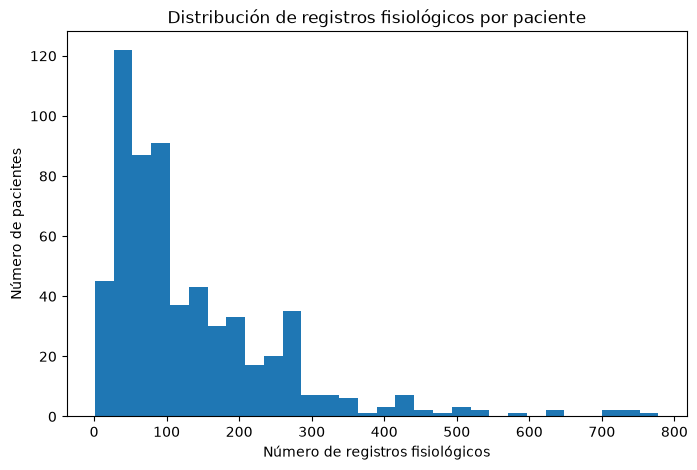

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    records_per_patient,
    bins=30
)

plt.xlabel("Número de registros fisiológicos")
plt.ylabel("Número de pacientes")
plt.title(
    "Distribución de registros fisiológicos por paciente"
)

plt.show()

### Diagrama de caja del número de registros por paciente

El diagrama de caja permite visualizar la mediana, los cuartiles, la dispersión
y la presencia potencial de valores extremos en el número de registros
fisiológicos disponibles por paciente.

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_33340/3468001742.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


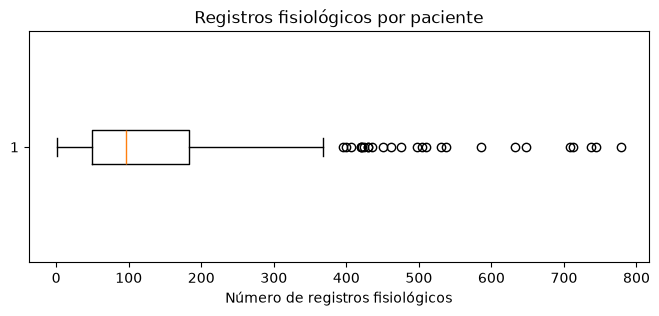

In [55]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    records_per_patient,
    vert=False
)

plt.xlabel("Número de registros fisiológicos")
plt.title(
    "Registros fisiológicos por paciente"
)

plt.show()

## Disponibilidad de registros EEG por paciente

Debido a que el EEG constituye la principal modalidad de interés para el
análisis posterior de señales, su disponibilidad se estudia de manera
independiente.

Se determina el número total de registros EEG, la cantidad de pacientes con
EEG disponible y la existencia de pacientes sin registros EEG.

In [56]:
eeg_df = records_df[
    records_df["Modality"] == "EEG"
].copy()

print(
    "Total de registros EEG:",
    len(eeg_df)
)

print(
    "Pacientes con EEG:",
    eeg_df["Patient"].nunique()
)

print(
    "Pacientes sin EEG:",
    records_df["Patient"].nunique()
    - eeg_df["Patient"].nunique()
)

Total de registros EEG: 36123
Pacientes con EEG: 607
Pacientes sin EEG: 0


### Disponibilidad de EEG en la cohorte

Se identificaron **36.123 registros EEG** correspondientes a los **607
pacientes** incluidos en el inventario.

Todos los pacientes presentan al menos un registro EEG disponible, por lo que
no se identificaron pacientes sin disponibilidad de EEG a nivel del inventario.

Este resultado describe únicamente la **disponibilidad de registros**. No
implica que todos los pacientes tengan la misma cantidad, duración, número de
canales o calidad de señal, aspectos que serán evaluados posteriormente.

### Número de registros EEG por paciente

Se calcula el número de registros EEG disponibles para cada paciente. Esta
variable permite estudiar la heterogeneidad en la cantidad de registros EEG
dentro de la cohorte.

In [58]:
eeg_per_patient = (
    eeg_df
    .groupby("Patient")
    .size()
    .rename("EEG_records")
)

eeg_per_patient.head(10)

Patient
0284    85
0286    63
0296     6
0299    30
0303    46
0306    46
0311    18
0312    53
0313    41
0316    77
Name: EEG_records, dtype: int64

### Estadísticas descriptivas de la disponibilidad de EEG

Se calculan estadísticas descriptivas sobre el número de registros EEG por
paciente, incluyendo media, desviación estándar, mínimo, cuartiles, mediana
y máximo.

In [59]:
eeg_per_patient.describe()

count    607.000000
mean      59.510708
std       43.509865
min        1.000000
25%       30.000000
50%       49.000000
75%       77.500000
max      389.000000
Name: EEG_records, dtype: float64

### Distribución del número de registros EEG por paciente

El histograma permite examinar la distribución del número de registros EEG
disponibles por paciente y detectar posibles concentraciones, asimetrías o
diferencias importantes en la disponibilidad de EEG dentro de la cohorte.

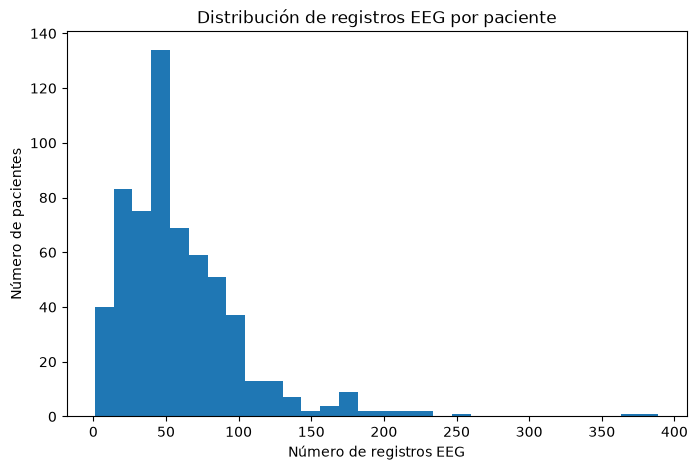

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(
    eeg_per_patient,
    bins=30
)

plt.xlabel("Número de registros EEG")
plt.ylabel("Número de pacientes")
plt.title(
    "Distribución de registros EEG por paciente"
)

plt.show()

### Diagrama de caja del número de registros EEG por paciente

El diagrama de caja complementa el análisis de distribución mostrando la
mediana, los cuartiles, la dispersión y posibles valores extremos en la
cantidad de registros EEG disponibles por paciente.

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_33340/1007537849.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


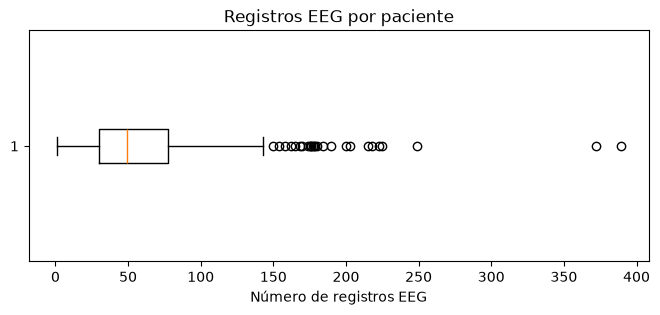

In [61]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    eeg_per_patient,
    vert=False
)

plt.xlabel("Número de registros EEG")
plt.title(
    "Registros EEG por paciente"
)

plt.show()

## Análisis de metadatos de los encabezados EEG (`.hea`)

Una vez caracterizada la disponibilidad de los registros EEG, se analizan
los metadatos contenidos en sus archivos de encabezado (`.hea`).

El objetivo es describir propiedades estructurales de las señales EEG sin
necesidad de descargar inicialmente todos los archivos de señal (`.mat`).

Las principales variables de interés son:

- Frecuencia de muestreo.
- Número de canales.
- Nombres de los canales.
- Número de muestras.
- Duración del registro.

In [62]:
import wfdb

record_path = patient_eeg_dir / record_name

header = wfdb.rdheader(
    str(record_path)
)

print("Registro:", record_name)
print("Frecuencia de muestreo:", header.fs, "Hz")
print("Número de canales:", header.n_sig)
print("Número de muestras:", header.sig_len)
print("Duración:", header.sig_len / header.fs, "segundos")
print("Canales:")
print(header.sig_name)

Registro: 0284_001_004_EEG
Frecuencia de muestreo: 500 Hz
Número de canales: 19
Número de muestras: 1578500
Duración: 3157.0 segundos
Canales:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


### Interpretación de un encabezado EEG

El archivo `.hea` contiene información estructural sobre el registro sin
contener directamente las muestras completas de la señal.

La duración del registro puede calcularse como:

\[
T = \frac{N}{f_s}
\]

donde:

- \(N\) es el número de muestras.
- \(f_s\) es la frecuencia de muestreo en Hz.
- \(T\) es la duración del registro en segundos.

### Construcción del inventario global de metadatos EEG

Después de validar la lectura de un archivo de encabezado EEG, el procedimiento
se extiende a todos los registros EEG identificados en el inventario.

En esta etapa se consultan únicamente los archivos `.hea`. Los archivos `.mat`,
que contienen las muestras completas de las señales, no se descargan.

Para cada registro EEG se extraen las siguientes características:

- Identificador del paciente.
- Identificador del registro.
- Frecuencia de muestreo.
- Número de canales.
- Número de muestras.
- Duración del registro en segundos.
- Nombres de los canales.

El resultado se almacena en un nuevo conjunto de datos denominado
`eeg_headers_df`, donde cada fila representa un registro EEG.

In [ ]:
eeg_headers = []

for i, row in eeg_df.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    header_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/{record_name}.hea"
    )

    response = requests.get(header_url)
    response.raise_for_status()

    lines = response.text.strip().splitlines()

    # First line of the WFDB header
    first_line = lines[0].split()

    record = first_line[0]
    n_channels = int(first_line[1])
    sampling_frequency = float(first_line[2])
    n_samples = int(first_line[3])

    duration_seconds = (
        n_samples / sampling_frequency
    )

    # Channel names are found at the end
    # of the following n_channels lines
    channel_names = [
        line.split()[-1]
        for line in lines[1:1 + n_channels]
    ]

    eeg_headers.append({
        "Patient": patient_id,
        "Record": record_name,
        "SamplingFrequency": sampling_frequency,
        "Channels": n_channels,
        "Samples": n_samples,
        "DurationSeconds": duration_seconds,
        "ChannelNames": channel_names
    })

    if (i + 1) % 1000 == 0:
        print(f"Procesados: {i + 1}")